<a href="https://colab.research.google.com/github/Anshu-kumar-singh/Iris_fower_classification_Basic_project/blob/main/IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

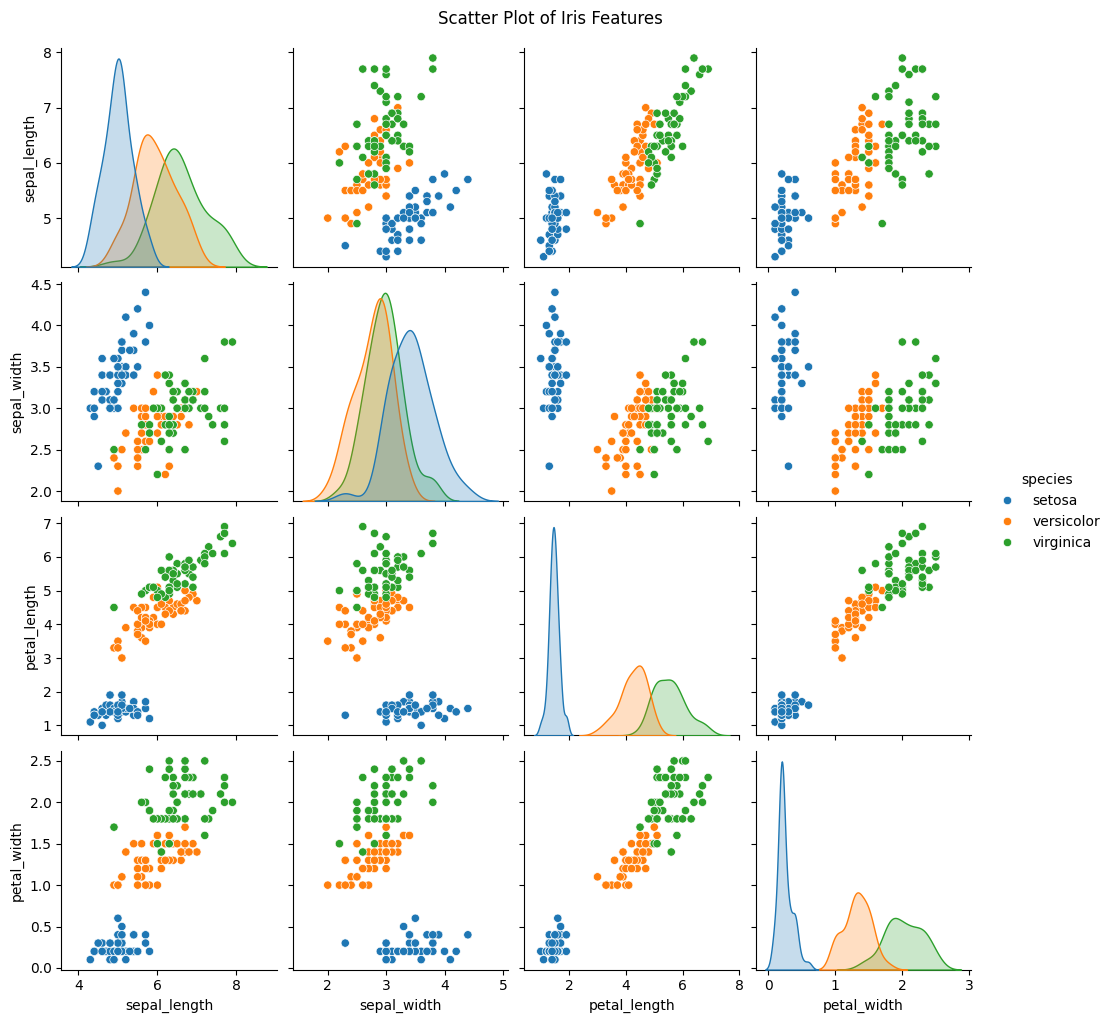


KNN Accuracy: 1.00
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


SVM Accuracy: 1.00
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Decision Tree Accuracy: 1.00
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

  

In [1]:
# Iris Flower Classification using Ensemble Learning

# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier

# Load Dataset
df = sns.load_dataset("iris")

# Visualize Data
sns.pairplot(df, hue="species")
plt.suptitle("Scatter Plot of Iris Features", y=1.02)
plt.show()

# Features and Labels
X = df.drop("species", axis=1)
y = df["species"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Create Models
knn = KNeighborsClassifier()
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

# Train Models Individually
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Individual Model Evaluation
for model, name in zip(
    [knn, svm, dt],
    ["KNN", "SVM", "Decision Tree"]
):
    y_pred = model.predict(X_test)

    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# Ensemble Voting Classifier
voting = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('svm', svm),
        ('dt', dt)
    ],
    voting='soft'
)

# Train Voting Classifier
voting.fit(X_train, y_train)

# Final Evaluation
y_pred_voting = voting.predict(X_test)

print("\nVoting Classifier Accuracy:",
      accuracy_score(y_test, y_pred_voting))

print(confusion_matrix(y_test, y_pred_voting))
print(classification_report(y_test, y_pred_voting))